# Graphical LASSO: Sparse Inverse Covariance Estimation

Given $n$ i.i.d. observations $X_1, \ldots, X_n \sim \mathcal{N}(0, \Sigma)$, the **graphical LASSO** (GLasso) estimates the **precision matrix** $\Theta = \Sigma^{-1}$ by maximizing the $\ell_1$-penalised log-likelihood:
$$
\hat{\Theta} = \arg\max_{\Theta \succ 0} \left\{ \log \det \Theta - \mathrm{tr}(S\Theta) - \lambda \|\Theta\|_1 \right\},
$$
where $S = \frac{1}{n} \sum_i X_i X_i^\top$ is the sample covariance and $\|\Theta\|_1 = \sum_{i,j} |\Theta_{ij}|$.

## Graphical model interpretation

In a Gaussian graphical model, $\Theta_{ij} = 0$ iff $X_i \perp X_j \mid X_{-\{i,j\}}$ (conditional independence). The $\ell_1$ penalty promotes sparsity in $\Theta$, **selecting the graph edges** (non-zero precision entries).

## Block-coordinate (GLASSO) algorithm

Friedman et al. (2008) solve the problem via **block-coordinate descent** on the bordered system. For each variable $j$, the update amounts to a Lasso regression:
$$
\hat{\beta} = \arg\min_\beta \frac{1}{2}\|W_{-j,-j}^{1/2}\beta - W_{-j,-j}^{-1/2} S_{-j,j}\|^2 + \lambda\|\beta\|_1,
$$
then $W_{-j,j} = W_{-j,-j}\hat\beta$.

## Regularisation path

As $\lambda$ increases, more edges are removed (sparser $\Theta$). At $\lambda_{\max} = \max_{i\neq j}|S_{ij}|$ the solution is diagonal (no edges). The **regularisation path** traces this evolution.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.covariance import GraphicalLasso, GraphicalLassoCV
from sklearn.datasets import make_spd_matrix
from ipywidgets import interact, FloatLogSlider

plt.rcParams['figure.dpi'] = 120

## Synthetic sparse graph

We generate a sparse precision matrix corresponding to a random sparse graph, draw samples, and recover the graph with GLasso.

In [2]:
rng = np.random.default_rng(17)
p = 12    # dimension
n_samples = 200

# Build a sparse precision matrix from a random graph
Theta_true = np.eye(p)
for i in range(p):
    for j in range(i+1, p):
        if rng.random() < 0.25:  # ~25% edge probability
            val = rng.choice([-0.6, 0.6])
            Theta_true[i, j] = val
            Theta_true[j, i] = val

# Make positive definite
eigmin = np.linalg.eigvalsh(Theta_true).min()
if eigmin < 0.1:
    Theta_true += (0.1 - eigmin + 0.05) * np.eye(p)

Sigma_true = np.linalg.inv(Theta_true)
X = rng.multivariate_normal(np.zeros(p), Sigma_true, n_samples)
S = np.cov(X.T)
print(f'Samples: {n_samples}, features: {p}')
print(f'True non-zero off-diagonal precision entries: {(np.abs(Theta_true) > 0.01).sum() - p}')

Samples: 200, features: 12
True non-zero off-diagonal precision entries: 34


## Fitting GLasso at a fixed $\lambda$

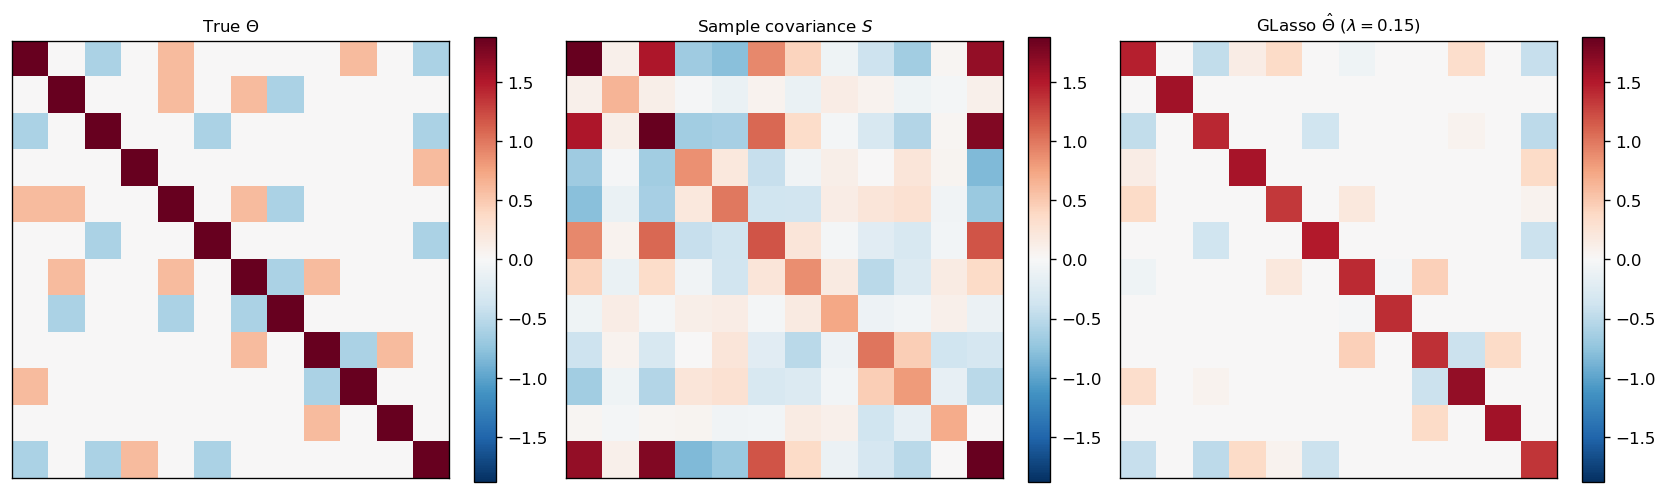

TP=26, FP=10, FN=8
Precision=0.72, Recall=0.76


In [3]:
lam = 0.15
glasso = GraphicalLasso(alpha=lam, max_iter=500).fit(X)
Theta_hat = glasso.precision_

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
vmax = np.abs(Theta_true).max()
for ax, (mat, title) in zip(axes, [
    (Theta_true, 'True $\\Theta$'),
    (S,          'Sample covariance $S$'),
    (Theta_hat,  fr'GLasso $\hat{{\Theta}}$ ($\lambda={lam}$)'),
]):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

# Precision
true_nonzero = (np.abs(Theta_true) > 0.05) & ~np.eye(p, dtype=bool)
hat_nonzero  = (np.abs(Theta_hat) > 1e-4) & ~np.eye(p, dtype=bool)
tp = (true_nonzero & hat_nonzero).sum()
fp = (~true_nonzero & hat_nonzero).sum()
fn = (true_nonzero & ~hat_nonzero).sum()
print(f'TP={tp}, FP={fp}, FN={fn}')
print(f'Precision={tp/(tp+fp+1e-9):.2f}, Recall={tp/(tp+fn+1e-9):.2f}')

## Regularisation path

As $\lambda$ grows, the estimated graph becomes sparser.

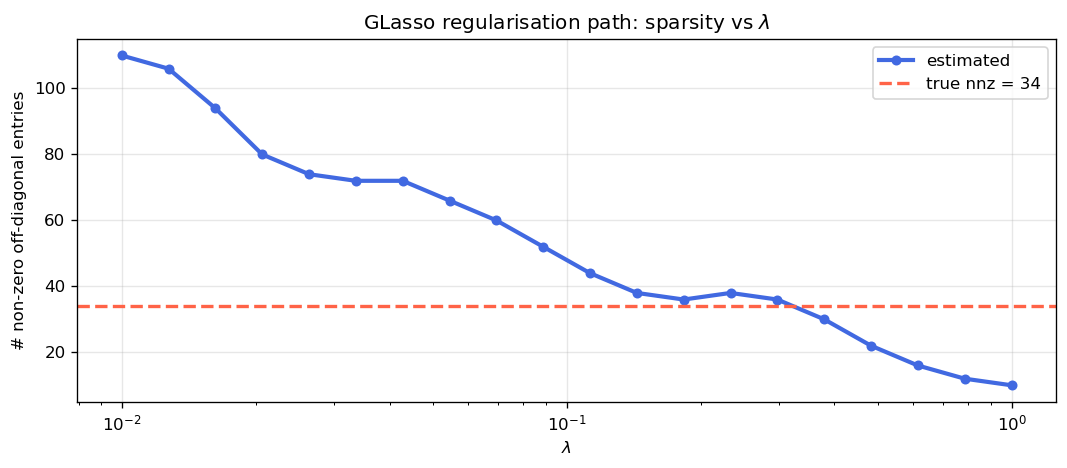

In [4]:
lam_values = np.logspace(-2, 0, 20)
nnz_list = []
for lam_i in lam_values:
    try:
        gl = GraphicalLasso(alpha=lam_i, max_iter=500).fit(X)
        nnz = ((np.abs(gl.precision_) > 1e-4) & ~np.eye(p, dtype=bool)).sum()
    except Exception:
        nnz = 0
    nnz_list.append(nnz)

true_nnz = true_nonzero.sum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lam_values, nnz_list, 'royalblue', lw=2.5, marker='o', ms=5, label='estimated')
ax.axhline(true_nnz, color='tomato', ls='--', lw=2, label=f'true nnz = {true_nnz}')
ax.set_xlabel('$\\lambda$'); ax.set_ylabel('# non-zero off-diagonal entries')
ax.set_title('GLasso regularisation path: sparsity vs $\\lambda$')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Interactive: visualise graph at different $\lambda$

In [5]:
def show_glasso(log_lam=-1.0):
    lam_i = 10**log_lam
    try:
        gl = GraphicalLasso(alpha=lam_i, max_iter=500).fit(X)
        Th = gl.precision_
    except Exception:
        print('Convergence failed'); return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    vmax_i = np.abs(Th).max()
    im = axes[0].imshow(Th, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    plt.colorbar(im, ax=axes[0], fraction=0.046)
    axes[0].set_title(fr'$\hat{{\Theta}}$ ($\lambda={lam_i:.3f}$)')
    axes[0].set_xticks([]); axes[0].set_yticks([])

    # Draw graph
    angle = 2*np.pi*np.arange(p)/p
    pos = np.column_stack([np.cos(angle), np.sin(angle)])
    for i in range(p):
        for j in range(i+1, p):
            if abs(Th[i,j]) > 1e-4:
                lw = 3*abs(Th[i,j])/vmax_i
                col = 'tomato' if Th[i,j] > 0 else 'royalblue'
                axes[1].plot(pos[[i,j],0], pos[[i,j],1], color=col, lw=lw, alpha=0.7)
    axes[1].scatter(pos[:,0], pos[:,1], s=200, c='white', edgecolors='black', zorder=5)
    for i in range(p):
        axes[1].text(pos[i,0]*1.12, pos[i,1]*1.12, str(i), ha='center', va='center', fontsize=9)
    axes[1].set_aspect('equal'); axes[1].axis('off')
    axes[1].set_title(f'Estimated graph (red=pos, blue=neg)')
    nnz_i = ((np.abs(Th) > 1e-4) & ~np.eye(p,dtype=bool)).sum()
    axes[1].set_xlabel(f'{nnz_i} edges')
    plt.tight_layout(); plt.show()

interact(show_glasso,
         log_lam=FloatLogSlider(value=-1.0, min=-2.0, max=0.0, step=0.1, description='$\\log_{10}\\lambda$'));

interactive(children=(FloatLogSlider(value=0.01, description='$\\log_{10}\\lambda$', max=0.0, min=-2.0), Outpu…

## Bibliographical resources

- Friedman, J., Hastie, T. and Tibshirani, R. (2008). Sparse inverse covariance estimation with the graphical lasso. *Biostatistics*, 9(3), 432–441.
- Meinshausen, N. and Bühlmann, P. (2006). High-dimensional graphs and variable selection with the lasso. *Annals of Statistics*, 34(3), 1436–1462.
- Yuan, M. and Lin, Y. (2007). Model selection and estimation in the Gaussian graphical model. *Biometrika*, 94(1), 19–35.
- Banerjee, O., El Ghaoui, L. and d'Aspremont, A. (2008). Model selection through sparse maximum likelihood estimation. *Journal of Machine Learning Research*, 9, 485–516.
- Lauritzen, S. L. (1996). *Graphical Models*. Oxford University Press.